**Retail Price -Exploratory Data analysis**

**Project Objective**

The main objective of this project is to perform a comprehensive Exploratory Data Analysis (EDA) on the 'Retail_price.csv' dataset. This analysis aims to understand the sales patterns, customer behavior, and product performance within the retail business. The insights gained will help in making data-driven decisions for business growth, marketing strategies, and inventory management.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("retail_price.csv")  # expects the file in this same folder
df["period_date"] = pd.to_datetime(df["month_year"], format="%d-%m-%Y")
df["comp_avg_price"] = df[["comp_1", "comp_2", "comp_3"]].mean(axis=1)
df["comp_avg_score"] = df[["ps1", "ps2", "ps3"]].mean(axis=1)

**Overview**

In [3]:
# === 1. Overview ===
print("Shape:", df.shape)
print(df.dtypes)
df.head()

Shape: (676, 33)
product_id                            object
product_category_name                 object
month_year                            object
qty                                    int64
total_price                          float64
freight_price                        float64
unit_price                           float64
product_name_lenght                    int64
product_description_lenght             int64
product_photos_qty                     int64
product_weight_g                       int64
product_score                        float64
customers                              int64
weekday                                int64
weekend                                int64
holiday                                int64
month                                  int64
year                                   int64
s                                    float64
volume                                 int64
comp_1                               float64
ps1                                  f

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price,period_date,comp_avg_price,comp_avg_score
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90,2017-05-01,116.950000,4.1
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95,2017-06-01,114.950000,4.1
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95,2017-07-01,113.616667,4.1
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95,2017-08-01,111.786601,4.1
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95,2017-09-01,99.749570,4.1


**Data Quality**

In [4]:
# === 2. Data quality ===
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
period_date 

**Time Coverage**

Date range: 2017-01-01 00:00:00 to 2018-08-01 00:00:00
Day-of-month values (all 1 = monthly data, not daily): [np.int32(1)]
Months of history per product — min/median/max: 5 13.0 20


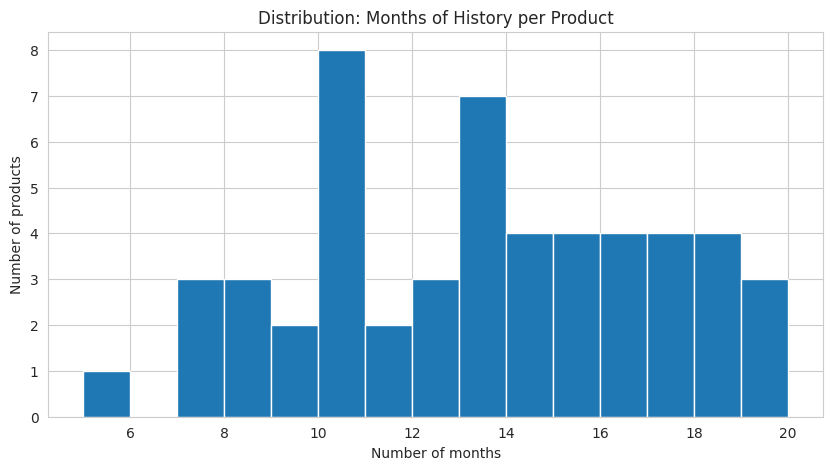

In [5]:
# === 3. Time coverage ===
print("Date range:", df["period_date"].min(), "to", df["period_date"].max())
print("Day-of-month values (all 1 = monthly data, not daily):", sorted(df["period_date"].dt.day.unique()))

rows_per_product = df.groupby("product_id").size()
print("Months of history per product — min/median/max:",
      rows_per_product.min(), rows_per_product.median(), rows_per_product.max())

rows_per_product.hist(bins=15)
plt.title("Distribution: Months of History per Product")
plt.xlabel("Number of months")
plt.ylabel("Number of products")
plt.show()

**Univariate Distributions**

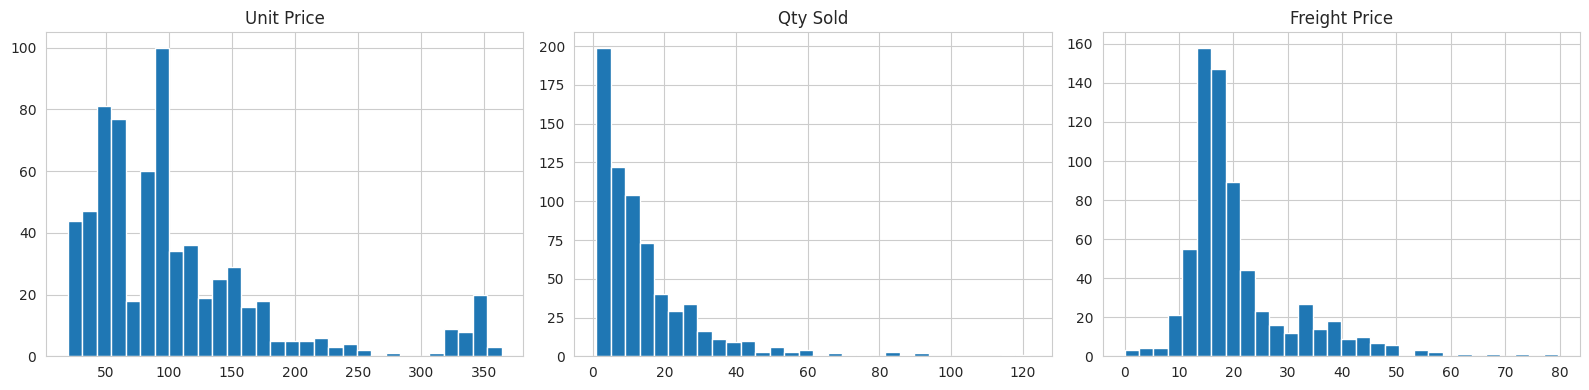

       unit_price         qty  freight_price
count  676.000000  676.000000     676.000000
mean   106.496800   14.495562      20.682270
std     76.182972   15.443421      10.081817
min     19.900000    1.000000       0.000000
25%     53.900000    4.000000      14.761912
50%     89.900000   10.000000      17.518472
75%    129.990000   18.000000      22.713558
max    364.000000  122.000000      79.760000


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["unit_price"].hist(bins=30, ax=axes[0]); axes[0].set_title("Unit Price")
df["qty"].hist(bins=30, ax=axes[1]); axes[1].set_title("Qty Sold")
df["freight_price"].hist(bins=30, ax=axes[2]); axes[2].set_title("Freight Price")
plt.tight_layout()
plt.show()
print(df[["unit_price", "qty", "freight_price"]].describe())

**Category Analysis**

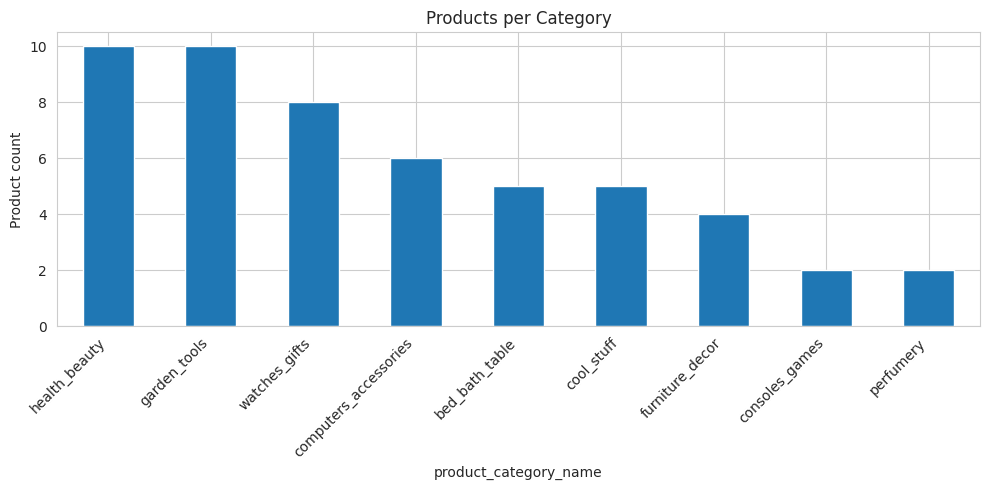

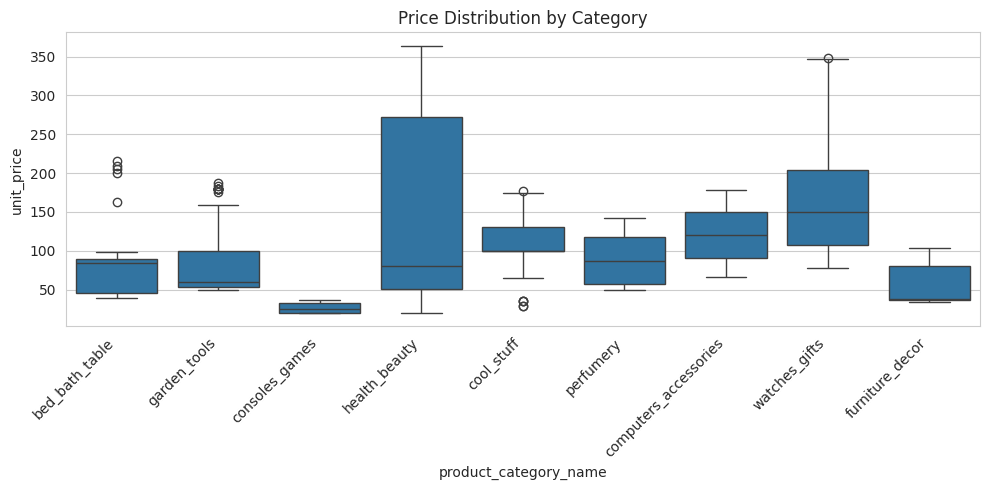

In [7]:
# === 5. Category analysis ===
category_counts = (df.drop_duplicates("product_id")
                      .groupby("product_category_name")["product_id"]
                      .count().sort_values(ascending=False))
category_counts.plot(kind="bar")
plt.title("Products per Category")
plt.ylabel("Product count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="product_category_name", y="unit_price")
plt.xticks(rotation=45, ha="right")
plt.title("Price Distribution by Category")
plt.tight_layout()
plt.show()

**Competitor price gap analysis**

                       avg_our_price  avg_competitor_price    gap
product_category_name                                            
health_beauty                 132.31                 61.10  71.21
garden_tools                   80.09                 58.71  21.38
watches_gifts                 164.88                145.88  19.00
cool_stuff                    107.86                101.28   6.58
bed_bath_table                 78.63                 76.86   1.77
consoles_games                 27.03                 27.03   0.00
perfumery                      89.35                 89.35   0.00
furniture_decor                60.15                 67.10  -6.95
computers_accessories         119.48                128.26  -8.78


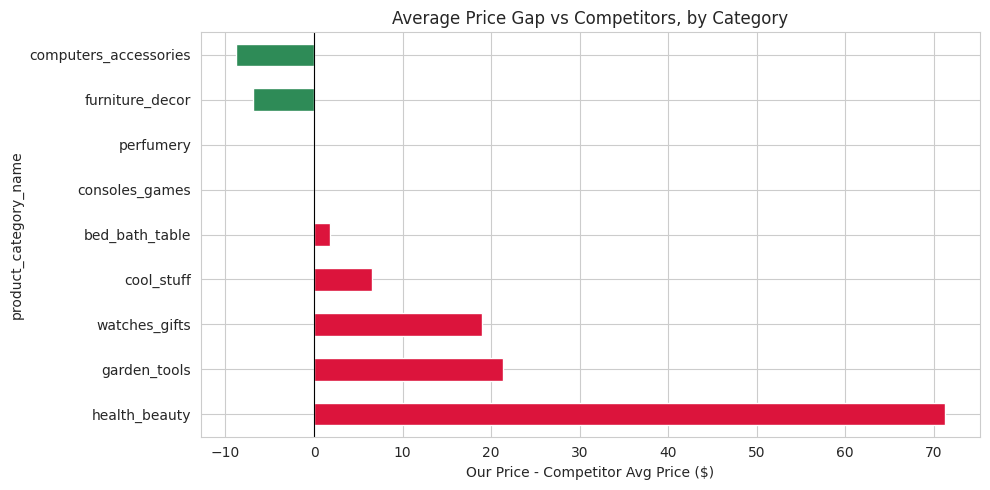

In [8]:
# === 6. Competitor price gap analysis ===
gap = df.groupby("product_category_name").agg(
    avg_our_price=("unit_price", "mean"),
    avg_competitor_price=("comp_avg_price", "mean"),
)
gap["gap"] = gap["avg_our_price"] - gap["avg_competitor_price"]
gap = gap.sort_values("gap", ascending=False)
print(gap.round(2))

colors = gap["gap"].apply(lambda x: "crimson" if x > 0 else "seagreen")
gap["gap"].plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Average Price Gap vs Competitors, by Category")
plt.xlabel("Our Price - Competitor Avg Price ($)")
plt.tight_layout()
plt.show()

**Correlation**

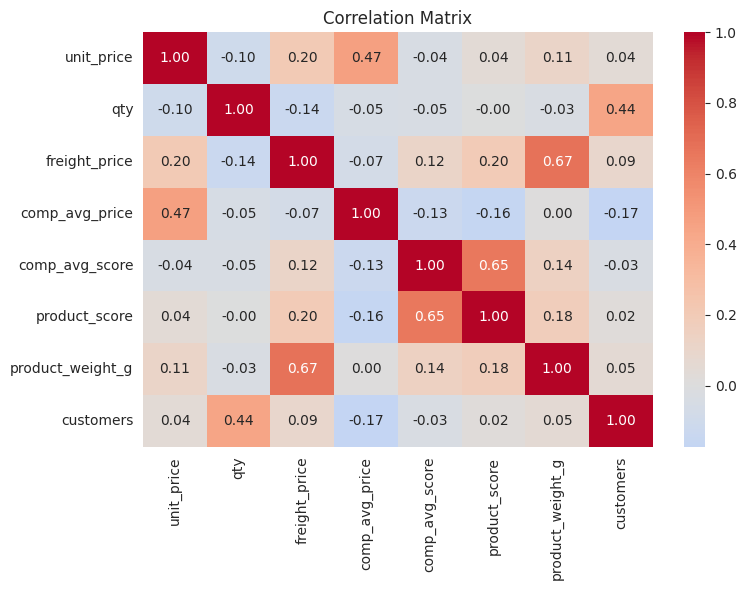

In [9]:
# === 7. Correlation ===
numeric_cols = ["unit_price", "qty", "freight_price", "comp_avg_price", "comp_avg_score",
                 "product_score", "product_weight_g", "customers"]
corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**Demand and price over time**

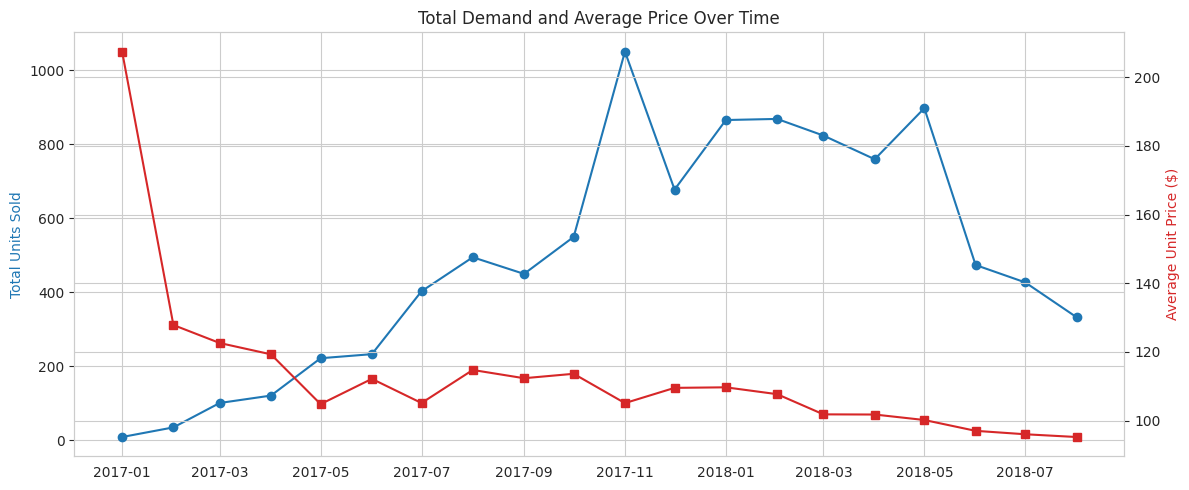

In [10]:
# === 8. Demand and price over time ===
monthly_trend = df.groupby("period_date").agg(
    total_qty=("qty", "sum"), avg_price=("unit_price", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly_trend["period_date"], monthly_trend["total_qty"], color="tab:blue", marker="o", label="Total units sold")
ax1.set_ylabel("Total Units Sold", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(monthly_trend["period_date"], monthly_trend["avg_price"], color="tab:red", marker="s", label="Avg unit price")
ax2.set_ylabel("Average Unit Price ($)", color="tab:red")
plt.title("Total Demand and Average Price Over Time")
fig.tight_layout()
plt.show()

**Outlier detection (IQR method)**

Price outliers: 45 rows, from products: ['health5' 'health2' 'watches7' 'watches1']
Qty outliers: 42 rows, from products: ['health3' 'garden4' 'computers5' 'garden10' 'computers6' 'garden6'
 'health10' 'health1' 'garden9' 'watches6' 'cool3' 'bed2' 'watches4'
 'watches3' 'furniture2' 'computers4' 'watches7' 'computers2' 'bed5']


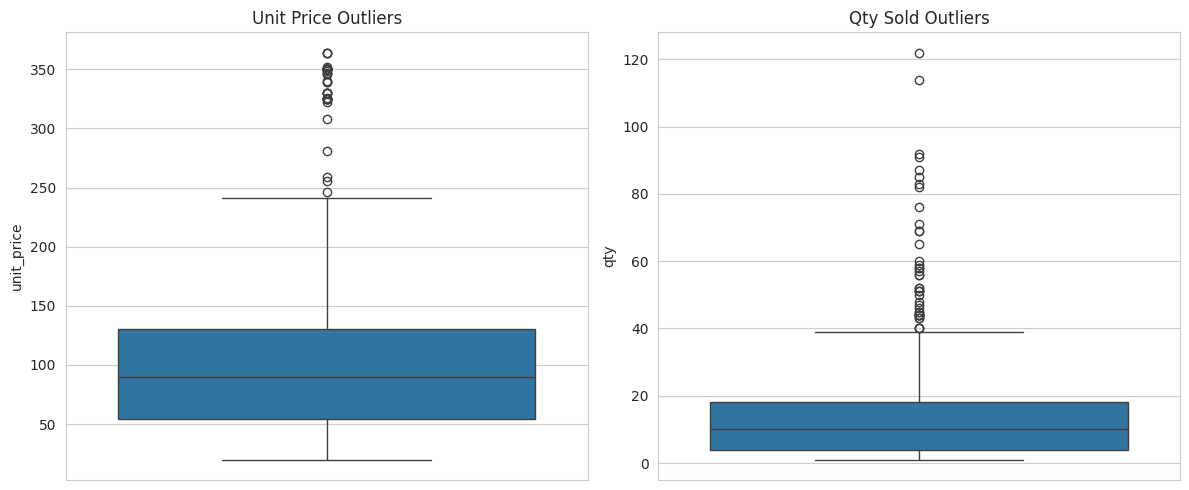

In [11]:
def find_outliers_iqr(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

price_outliers = df[find_outliers_iqr(df["unit_price"])]
qty_outliers = df[find_outliers_iqr(df["qty"])]
print(f"Price outliers: {len(price_outliers)} rows, from products:", price_outliers["product_id"].unique())
print(f"Qty outliers: {len(qty_outliers)} rows, from products:", qty_outliers["product_id"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["unit_price"], ax=axes[0]); axes[0].set_title("Unit Price Outliers")
sns.boxplot(y=df["qty"], ax=axes[1]); axes[1].set_title("Qty Sold Outliers")
plt.tight_layout()
plt.show()

**Statistical significance of category price differences**

In [12]:
categories = df["product_category_name"].unique()
groups = [df[df["product_category_name"] == c]["unit_price"].values for c in categories]
h_stat, p_value = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p-value = {p_value:.4g}")
print("-> category is a statistically significant factor in price" if p_value < 0.05
      else "-> cannot rule out category price differences are due to chance")
print("Sample size per category (note: some are small, e.g. 2 products):")
print(df.groupby("product_category_name")["product_id"].nunique().sort_values())

Kruskal-Wallis H = 227.28, p-value = 1.115e-44
-> category is a statistically significant factor in price
Sample size per category (note: some are small, e.g. 2 products):
product_category_name
consoles_games            2
perfumery                 2
furniture_decor           4
bed_bath_table            5
cool_stuff                5
computers_accessories     6
watches_gifts             8
garden_tools             10
health_beauty            10
Name: product_id, dtype: int64


**Price-demand relationship (elasticity-style view)**

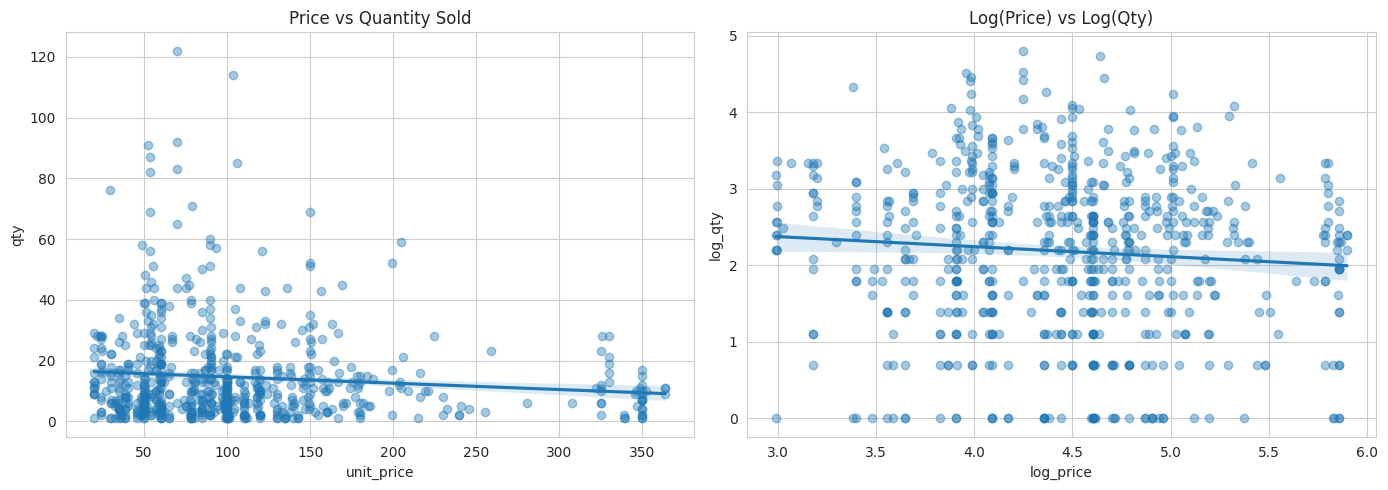

Price-Qty correlation: r=-0.103, p=0.007114
Log-log slope (elasticity estimate): -0.131  (r^2=0.007, p=0.03552)
Note: r^2 here is very low -- price alone explains under 1% of demand variation.


In [13]:
df["log_price"] = np.log(df["unit_price"])
df["log_qty"] = np.log(df["qty"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=df, x="unit_price", y="qty", ax=axes[0], scatter_kws={"alpha": 0.4})
axes[0].set_title("Price vs Quantity Sold")
sns.regplot(x=df["log_price"], y=df["log_qty"], ax=axes[1], scatter_kws={"alpha": 0.4})
axes[1].set_title("Log(Price) vs Log(Qty)")
plt.tight_layout()
plt.show()

corr_r, corr_p = stats.pearsonr(df["unit_price"], df["qty"])
slope, intercept, r, p, se = stats.linregress(df["log_price"], df["log_qty"])
print(f"Price-Qty correlation: r={corr_r:.3f}, p={corr_p:.4g}")
print(f"Log-log slope (elasticity estimate): {slope:.3f}  (r^2={r**2:.3f}, p={p:.4g})")
print("Note: r^2 here is very low -- price alone explains under 1% of demand variation.")

**Price volatility per product**

Most volatile pricing (top 5 products):
               mean     std  count     cv
product_id                               
cool3        42.000  15.903      7  0.379
computers5  100.244  29.975      8  0.299
consoles1    28.242   7.099     12  0.251
consoles2    25.584   5.763     10  0.225
watches8    184.505  39.548     10  0.214

Most stable / fixed pricing (bottom 5 products):
               mean    std  count     cv
product_id                              
health2     326.992  2.487     13  0.008
computers6  149.957  0.161      8  0.001
watches3     77.988  0.046     15  0.001
health1      84.990  0.000      9  0.000
health4      29.900  0.000     11  0.000


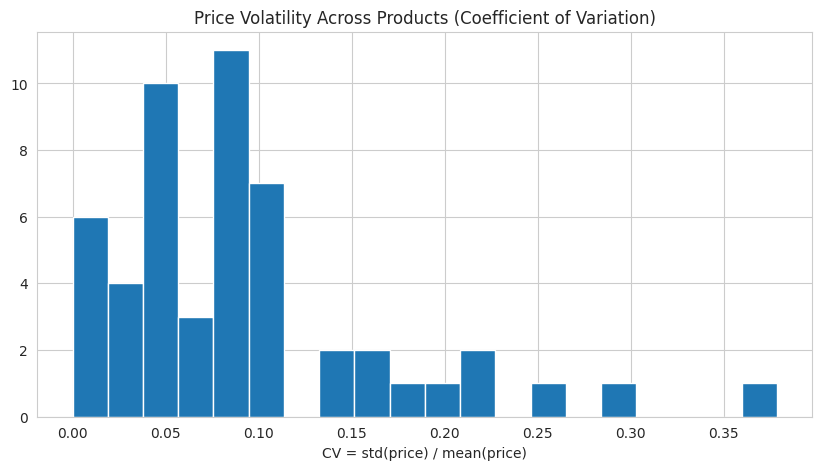

In [14]:
volatility = df.groupby("product_id")["unit_price"].agg(["mean", "std", "count"])
volatility["cv"] = volatility["std"] / volatility["mean"]
volatility = volatility.sort_values("cv", ascending=False)
print("Most volatile pricing (top 5 products):")
print(volatility.head(5).round(3))
print("\nMost stable / fixed pricing (bottom 5 products):")
print(volatility.tail(5).round(3))

volatility["cv"].dropna().hist(bins=20)
plt.title("Price Volatility Across Products (Coefficient of Variation)")
plt.xlabel("CV = std(price) / mean(price)")
plt.show()

**Products sharing near-identical competitor benchmarks**

In [15]:
comp_signature = df.groupby("product_id")[["comp_1", "comp_2", "comp_3"]].mean().round(1)
dup_signatures = comp_signature[comp_signature.duplicated(keep=False)].sort_values(["comp_1", "comp_2", "comp_3"])
print("Products with near-identical average competitor prices to another product:")
print(dup_signatures if len(dup_signatures) else "None found")

Products with near-identical average competitor prices to another product:
            comp_1  comp_2  comp_3
product_id                        
garden10      54.9    55.0    55.0
garden6       54.9    55.0    55.0
garden7       54.9    55.0    55.0
garden2       55.2    55.3    55.3
garden9       55.2    55.3    55.3


**Competitive positioning map**

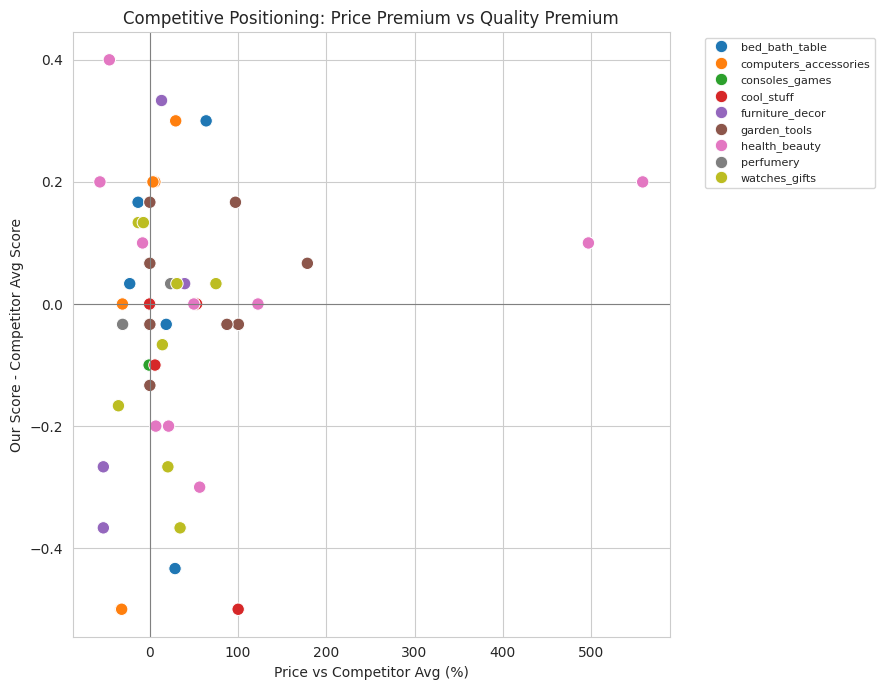

In [16]:
latest = df.sort_values("period_date").groupby("product_id").last().reset_index()
latest["price_vs_comp_pct"] = (latest["unit_price"] - latest["comp_avg_price"]) / latest["comp_avg_price"] * 100
latest["score_vs_comp"] = latest["product_score"] - latest["comp_avg_score"]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=latest, x="price_vs_comp_pct", y="score_vs_comp", hue="product_category_name", s=80)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("Price vs Competitor Avg (%)")
plt.ylabel("Our Score - Competitor Avg Score")
plt.title("Competitive Positioning: Price Premium vs Quality Premium")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()